In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.plot_utils import setup_matplotlib

In [29]:
setup_matplotlib()

In [30]:
file_name = f'square_20251017'
runs = [1, 2, 3, 4, 5]
df_real_dict = {}

for run in runs:
    try:
        file_name_real = f'{file_name}_run{run}.csv'
        df_real = pd.read_csv(os.path.join('../data/real/processed/train/', file_name_real))
        # Store dynamically
        df_real_dict[f'run{run}'] = df_real
    except Exception as e:
        print(e)
        continue

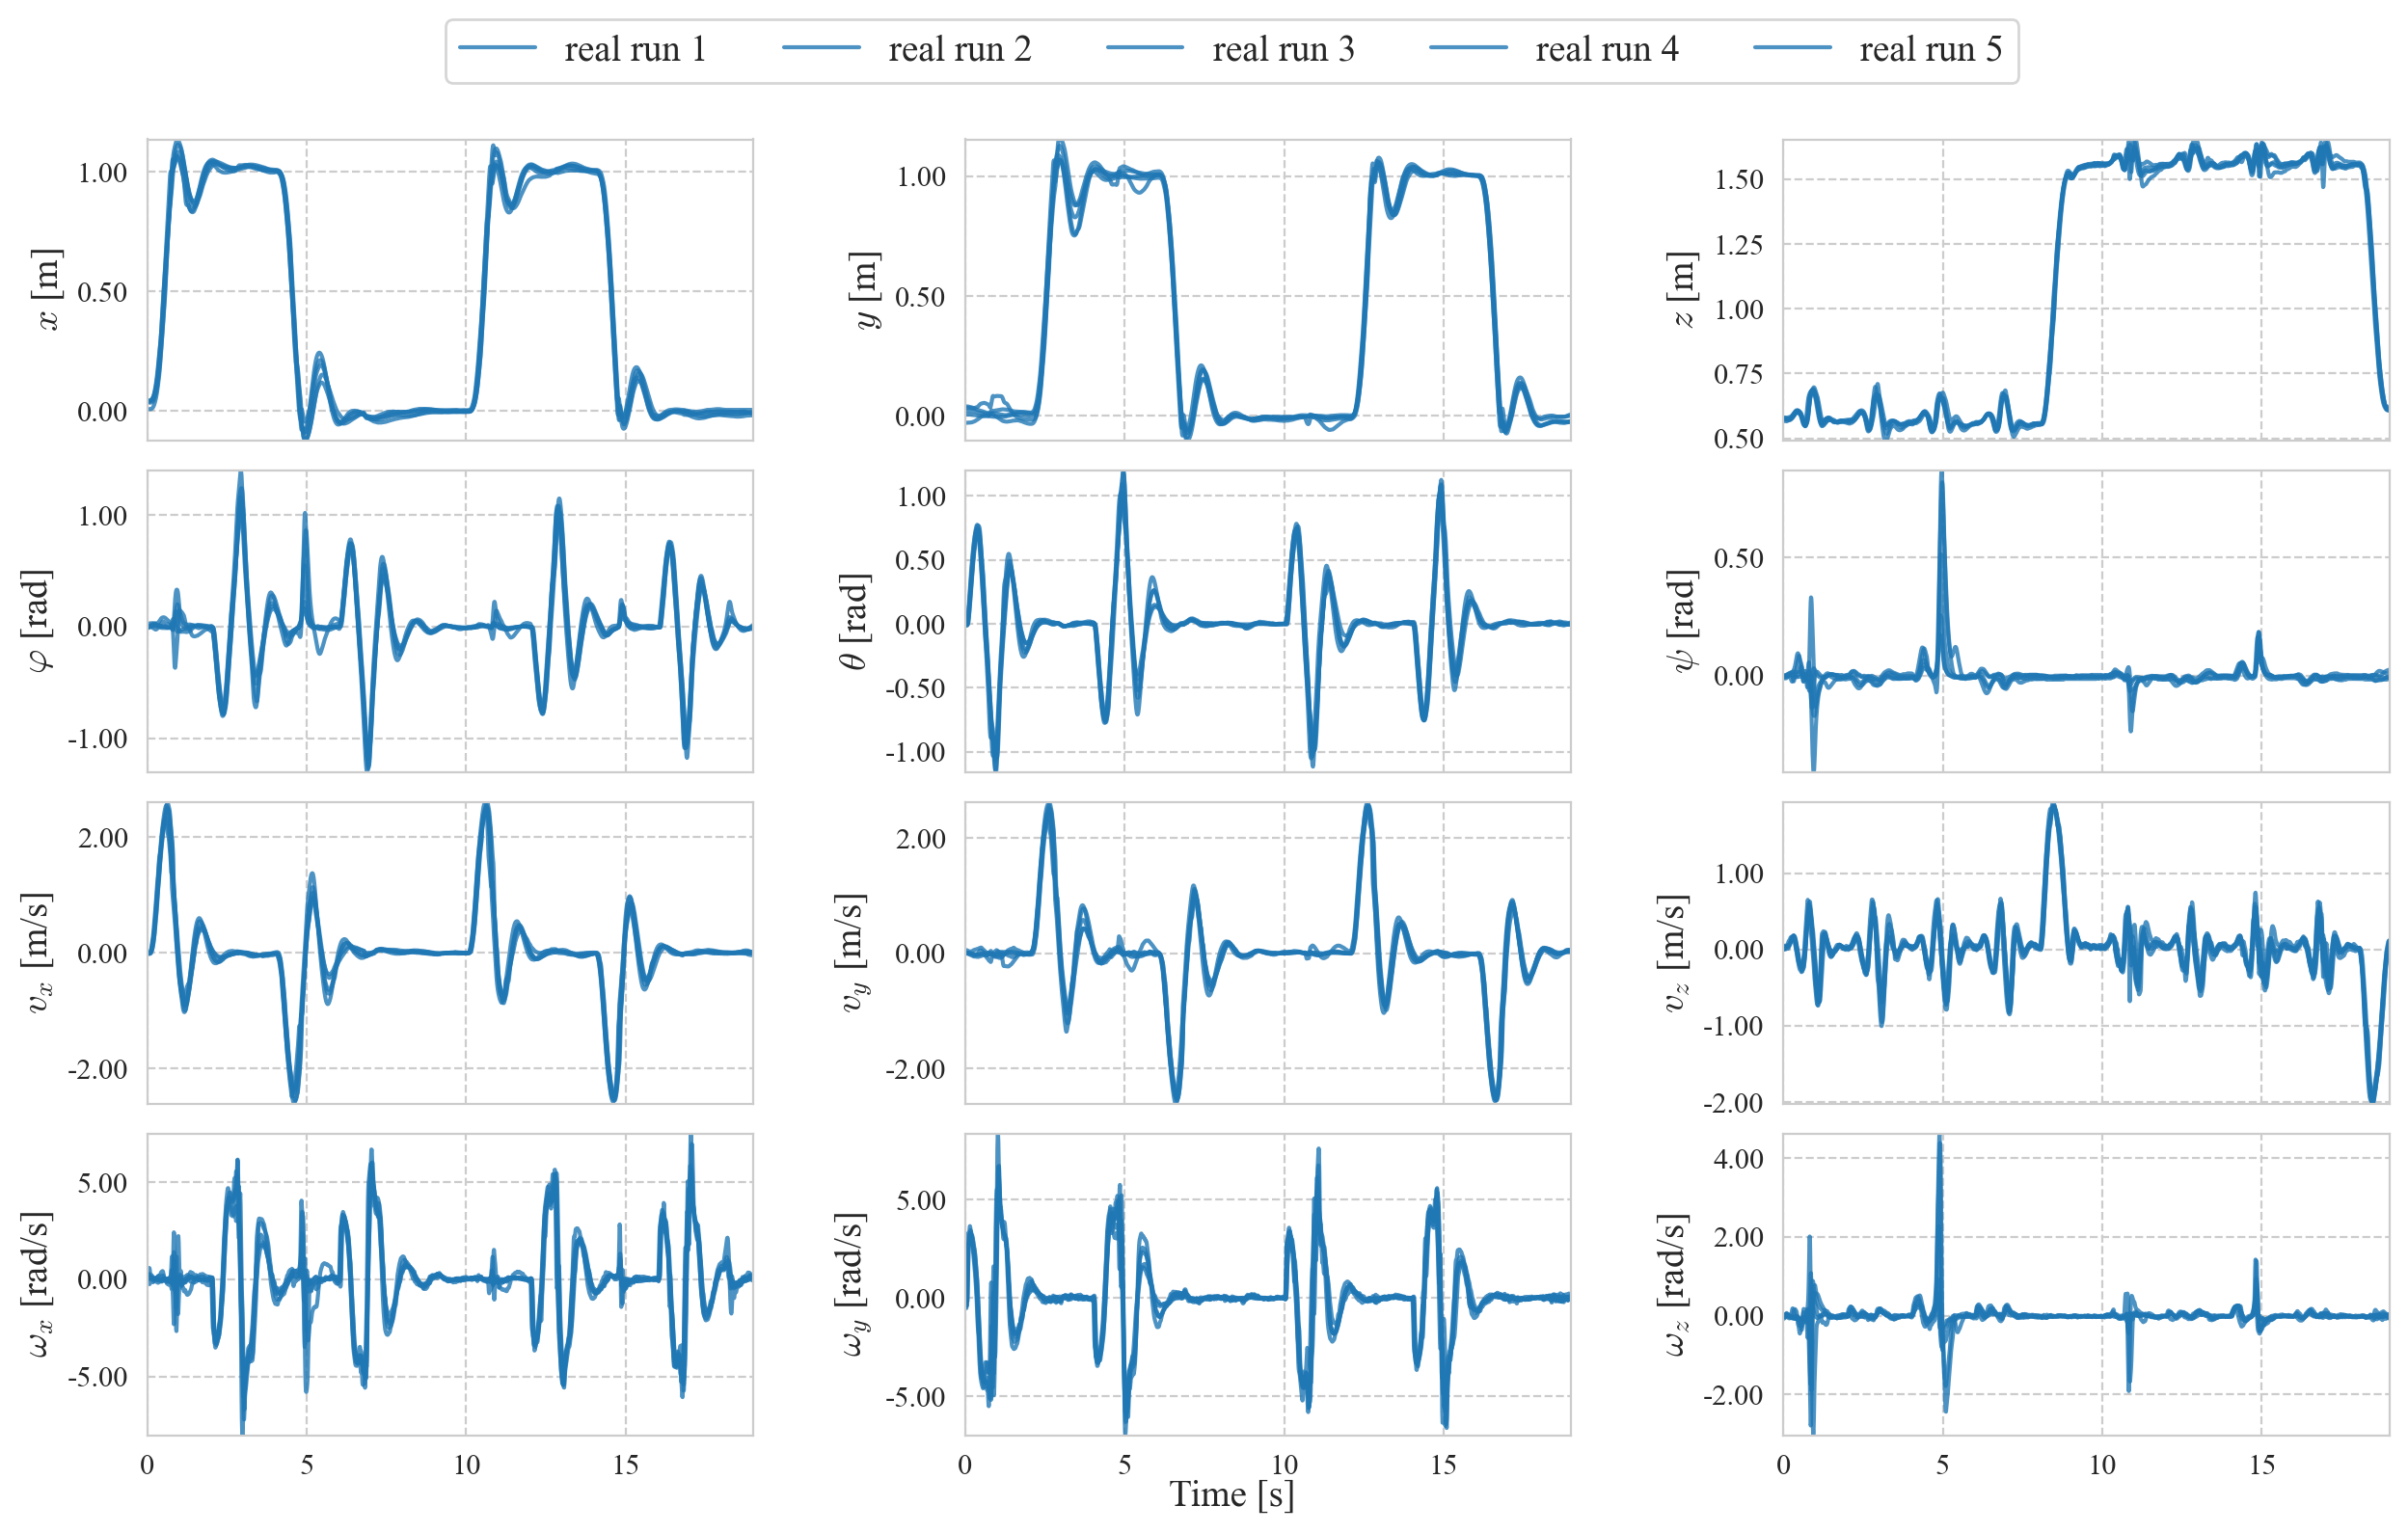

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


# --- Create 4x4 layout ---
fig, axs = plt.subplots(4, 3, figsize=(15, 8), sharex=True, dpi=200)

# --- Define state variables (fill first 3 columns) ---
state_cols = [
    ['x', 'y', 'z'],
    ['roll', 'pitch', 'yaw'],
    ['vx', 'vy', 'vz'],
    ['wx', 'wy', 'wz']
]
state_labels = [
    ['$x$ [m]', '$y$ [m]', '$z$ [m]'],
    [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
    [r'$v_x$ [m/s]', '$v_y$ [m/s]', '$v_z$ [m/s]'],
    [r'$\omega_x$ [rad/s]', r'$\omega_y$ [rad/s]', r'$\omega_z$ [rad/s]']
]

# --- Colors / styles for runs ---
colors = plt.cm.tab10.colors  # up to 10 distinct colors

# --- Plot states ---
for r in range(4):
    for c in range(3):
        col = state_cols[r][c]
        ax = axs[r, c]

        # All real runs
        for i, (name, df_real) in enumerate(df_real_dict.items()):
            label = f"real run {i+1}" if (r == 0 and c == 0) else None
            ax.plot(df_real['t'], df_real[col], color=colors[0], alpha=0.8, label=label)

        ax.set_ylabel(state_labels[r][c])
        ax.grid(True)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# --- Shared X label ---
fig.text(0.5, 0.04, "Time [s]", ha='center', va='center', fontsize=14)

# --- Combined legend ---
handles, labels = [], []
for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label and label not in labels:
            handles.append(handle)
            labels.append(label)
fig.legend(handles, labels, loc='upper center', ncols=6, bbox_to_anchor=(0.5, 1.01))

# --- Layout tweaks ---
plt.subplots_adjust(top=0.92, bottom=0.08, hspace=0.1, wspace=0.35)
plt.show()

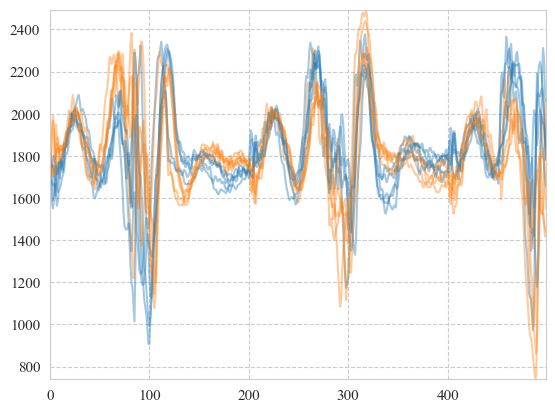

In [32]:
N_start = 0
N_end = N_start + 500
for i, (name, df_real) in enumerate(df_real_dict.items()):
    plt.plot(df_real['m1_rads'][N_start:N_end], color='tab:blue', alpha=0.4, label=f'real run {i+1}')
    plt.plot(df_real['m3_rads'][N_start:N_end], color='tab:orange', alpha=0.4, label=f'real run {i+1}')

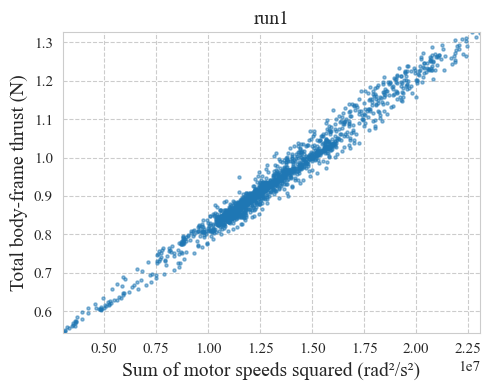

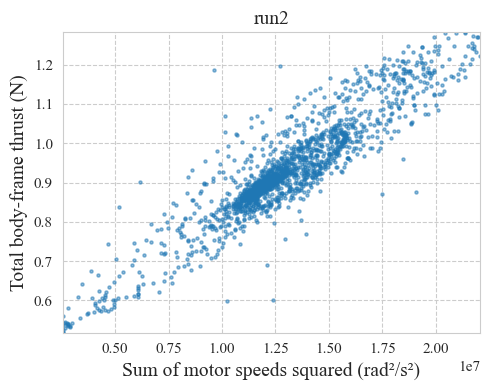

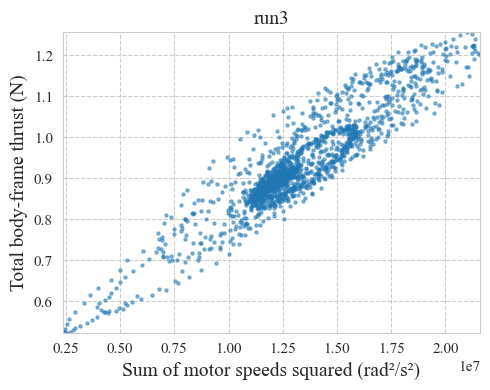

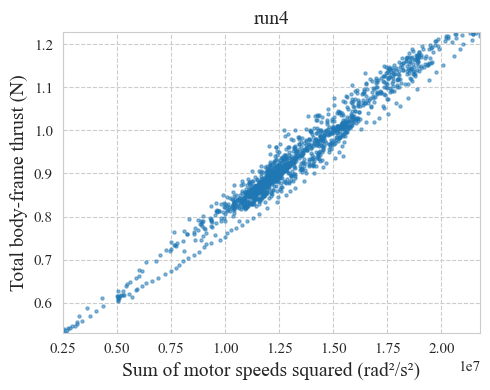

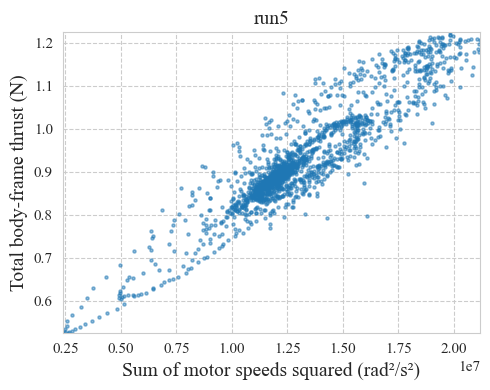

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

m = 0.045   # kg
g = 9.81    # m/s^2
L = 0.035   # m
J = np.diag([2.3951e-5, 2.3951e-5, 3.2347e-5])  # kg·m²

for name, df_real in df_real_dict.items():
    # --- Normalize quaternion just in case ---
    quat = df_real[["qx", "qy", "qz", "qw"]].to_numpy()
    quat /= np.linalg.norm(quat, axis=1, keepdims=True)

    # --- Transform accelerations (world → body) ---
    ag_wf = df_real[["ax", "ay", "az"]].to_numpy()       # world-frame acceleration
    r = R.from_quat(quat)
    ag_bf = r.apply(ag_wf, inverse=True)                 # body-frame acceleration
    df_real[["ax_body", "ay_body", "az_body"]] = ag_bf   # store it

    # --- Compute total thrust from acceleration ---
    # (assuming z-axis points downward in world frame)
    # T_bf_z = -m * (a_bz - g_body) if you want vertical thrust
    # here we take the *body-frame z-acceleration* as proxy
    T_bf = m * (ag_bf[:, 2] + g)   # N (body-frame z-axis, adding gravity)

    # --- Compute motor thrust proxy (sum of squared speeds) ---
    motor_cols = [f"m{i}_rads2" for i in range(1, 5)]
    T_mot = df_real[motor_cols].sum(axis=1)              # sum of ω² per sample

    # --- Scatter plot for correlation (normalized) ---
    plt.figure(figsize=(5, 4))
    plt.scatter(T_mot.shift(3), T_bf, s=5, alpha=0.5)
    plt.xlabel("Sum of motor speeds squared (rad²/s²)")
    plt.ylabel("Total body-frame thrust (N)")
    plt.title(f"{name}")
    plt.grid(True)
    plt.tight_layout()

    # Optionally: store results back
    df_real["T_bf"] = T_bf
    df_real["T_mot_sum"] = T_mot
    df_real_dict[name] = df_real

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

t_vec = df_sim['t']

# --- Create 4x4 layout ---
fig, axs = plt.subplots(4, 4, figsize=(20, 10), sharex=True, dpi=200)

# --- Define state variables (fill first 3 columns) ---
state_cols = [
    ['x', 'y', 'z'],
    ['roll', 'pitch', 'yaw'],
    ['vx', 'vy', 'vz'],
    ['wx', 'wy', 'wz']
]
state_labels = [
    ['$x$ [m]', '$y$ [m]', '$z$ [m]'],
    [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
    [r'$v_x$ [m/s]', '$v_y$ [m/s]', '$v_z$ [m/s]'],
    [r'$\omega_x$ [rad/s]', r'$\omega_y$ [rad/s]', r'$\omega_z$ [rad/s]']
]

# --- Inputs (last column) ---
input_cols = ['thrust', 'torque_roll', 'torque_pitch', 'torque_yaw']
input_labels = ['$T$ [N]', r'$\tau_{\varphi}$ [Nm]', r'$\tau_{\theta}$ [Nm]', r'$\tau_{\psi}$ [Nm]']

# --- Colors / styles for runs ---
colors = plt.cm.tab10.colors  # up to 10 distinct colors

# --- Plot states ---
for r in range(4):
    for c in range(3):
        col = state_cols[r][c]
        ax = axs[r, c]

        # All real runs
        for i, (name, df_real) in enumerate(df_real_dict.items()):
            label = f"real run {i+1}" if (r == 0 and c == 0) else None  # label only once for legend clarity
            ax.plot(df_real['t'], df_real[col], color=colors[i % len(colors)], alpha=0.8, label=label)
            # if f'{col}_r' in df_real.columns:
            #     ax.plot(t_vec, df_real[f'{col}_r'], color='green--', linestyle="--", label="sim ref")
            #

        ax.set_ylabel(state_labels[r][c])
        ax.grid(True)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# --- Plot inputs (last column) ---
for r in range(4):
    col = input_cols[r]
    ax = axs[r, 3]
    # All real runs
    for i, (name, df_real) in enumerate(df_real_dict.items()):
        label = f"real input run {i+1}" if r == 0 else None
        ax.plot(df_real['t'], df_real[col], color=colors[i % len(colors)], alpha=0.8, linestyle='--', label=label)

    ax.set_ylabel(input_labels[r])
    ax.grid(True)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# --- Shared X label ---
fig.text(0.5, 0.04, "Time [s]", ha='center', va='center', fontsize=14)

# --- Combined legend ---
handles, labels = [], []
for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label and label not in labels:
            handles.append(handle)
            labels.append(label)
fig.legend(handles, labels, loc='upper center', ncols=6, bbox_to_anchor=(0.5, 1.01))

# --- Layout tweaks ---
plt.subplots_adjust(top=0.92, bottom=0.08, hspace=0.1, wspace=0.35)
plt.show()

NameError: name 'df_sim' is not defined

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


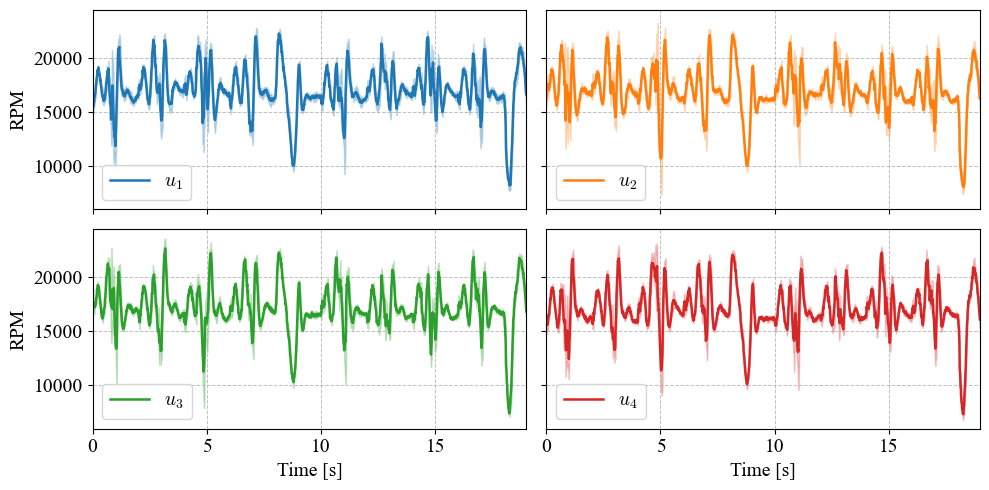

In [384]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
axes = axes.flatten()
motors = ['m1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm']
labels = ['$u_1$', '$u_2$', '$u_3$', '$u_4$']
colors = ['C0', 'C1', 'C2', 'C3']

# Determine common time vector (min length across runs)
min_len = min(len(df['t']) for df in df_real_dict.values())
t = df_real_dict[list(df_real_dict.keys())[0]]['t'].values[:min_len]

for i, (motor, label, color) in enumerate(zip(motors, labels, colors)):
    ax = axes[i]

    runs = np.stack([df[motor].values[:min_len] for df in df_real_dict.values()], axis=0) / 6
    mean = runs.mean(axis=0)
    std = runs.std(axis=0)

    ax.plot(t, mean, label=label, color=color, linewidth=1.8)
    ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.25)
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.8)

    # Label only left and bottom plots
    if i % 2 == 0:
        ax.set_ylabel('RPM')
    if i >= 2:
        ax.set_xlabel('Time [s]')

    # Automatically place legend where it doesn’t overlap data
    ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.savefig('inputs_square.pdf')
plt.show()


In [385]:
def plot_reference_trajectory(X_ref, title="Melon", two_column=False):
    """
    Create and save a 3D static plot of the reference trajectory (paper-ready).

    Args:
        X_ref: (N, 3) array of reference positions [x, y, z]
        title: optional plot title
        two_column: if True, set figure width for two-column layout
        filename: PDF filename to save
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    filename = f"{title.lower().replace(' ', '')}.pdf"
    # Figure size: match Elsevier CAS-DC column width
    if two_column:
        fig = plt.figure(figsize=(7.25, 3.5))  # two-column
    else:
        fig = plt.figure(figsize=(3.54, 2.8))  # single-column

    ax = fig.add_subplot(111, projection='3d')

    # Plot trajectory
    ax.plot(X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
            color='tab:blue', linewidth=1.8)

    # Labels and title
    ax.set_xlabel(r"$X$ [m]")
    ax.set_ylabel(r"$Y$ [m]")
    ax.zaxis.set_rotate_label(False)  # disable automatic rotation
    ax.set_zlabel(r"$Z$ [m]", rotation=90)
    # ax.set_title(title, fontsize=14, y=1.05)

    # Equal aspect ratio
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_zlim(0, 2)

    # View and style
    # ax.set_box_aspect([1, 1, 1])          # Equal aspect ratio (very important)
    # ax.set_proj_type('ortho')             # Switch to orthographic projection
    ax.view_init(elev=35, azim=25)
    ax.grid(True, linestyle="--", linewidth=0.5)

    # Adjust layout to avoid clipping
    plt.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=0.95)
    plt.tight_layout(pad=0.5)

    # Save as vector PDF (no cropping issues)
    # plt.savefig(filename, bbox_inches='tight', pad_inches=0.3)
    print(f"Saved figure as: {filename}")

    plt.show()

Saved figure as: square.pdf


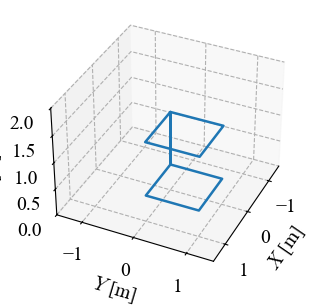

In [386]:
plot_reference_trajectory(df_sim[['x_r','y_r','z_r']].values, title=file_name.split("_")[0])

In [387]:
from idsia_mpc.control_engineering_practice.plot_utils import animate_sim_vs_real

# animate_sim_vs_real(df_sim, df_real_dict['run1'], gif_filename=f'figures/gifs/{file_name}.gif')

✅ run1: Body-frame acceleration and velocity stored


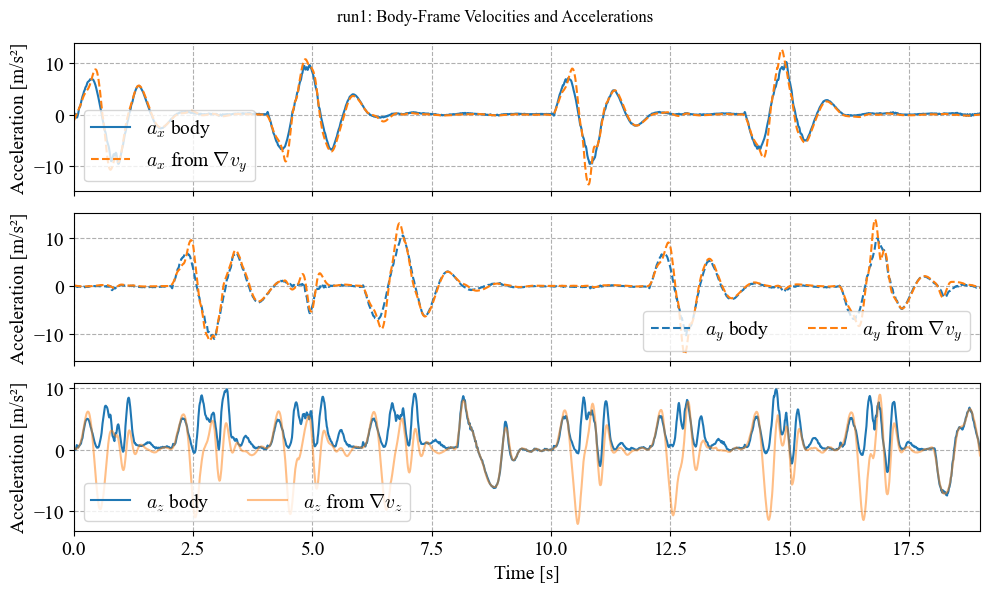

✅ run2: Body-frame acceleration and velocity stored


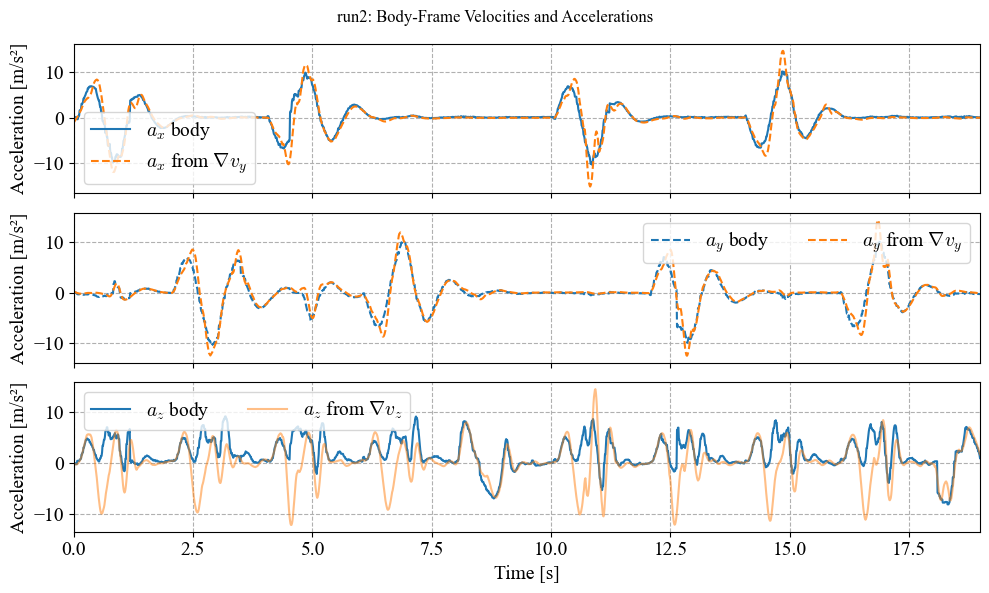

✅ run3: Body-frame acceleration and velocity stored


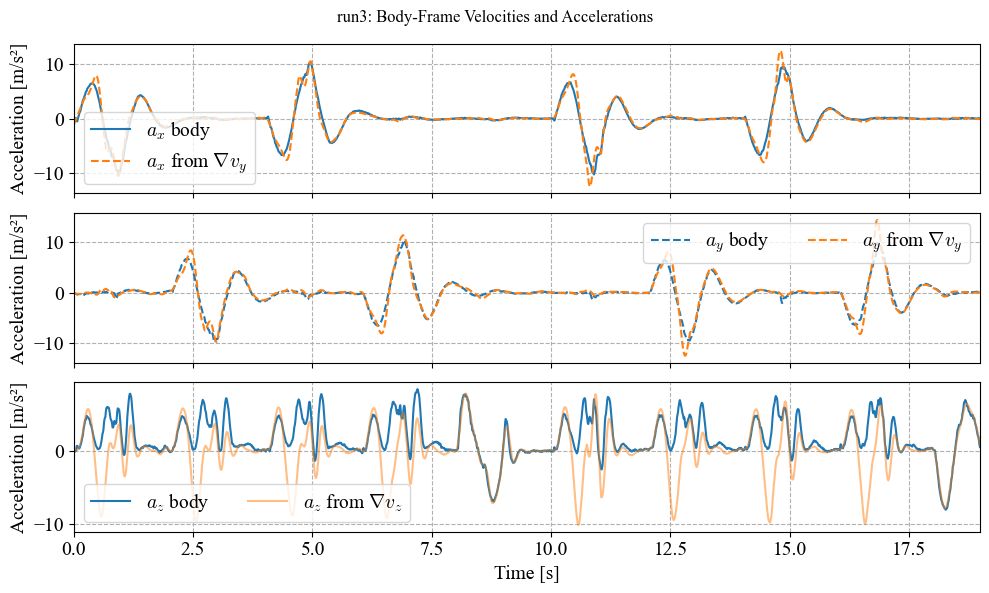

✅ run4: Body-frame acceleration and velocity stored


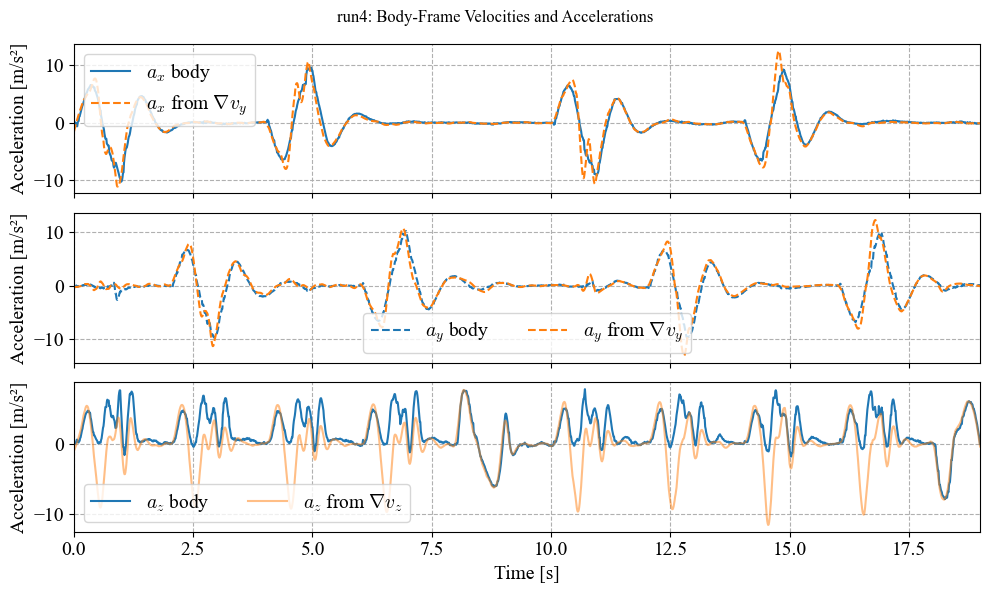

In [388]:
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

for i, (name, df_real) in enumerate(df_real_dict.items()):
    # --- Extract arrays from dataframe ---
    qw = df_real['qw'].to_numpy()
    qx = df_real['qx'].to_numpy()
    qy = df_real['qy'].to_numpy()
    qz = df_real['qz'].to_numpy()

    vx_w = df_real['vx'].to_numpy()
    vy_w = df_real['vy'].to_numpy()
    vz_w = df_real['vz'].to_numpy()

    ax_w = df_real['ax'].to_numpy()
    ay_w = df_real['ay'].to_numpy()
    az_w = df_real['az'].to_numpy() - 9.81  # remove gravity

    # --- Build rotation (body→world) ---
    r = R.from_quat(np.column_stack([qx, qy, qz, qw]))
    # --- Compute world→body rotation ---
    r_inv = r.inv()

    # --- Transform acceleration and velocity into body frame ---
    acc_world = np.column_stack([ax_w, ay_w, az_w])
    acc_body_ms2 = r_inv.apply(acc_world)

    vel_world = np.column_stack([vx_w, vy_w, vz_w])
    vel_body = r_inv.apply(vel_world)

    # --- Store in dataframe ---
    df_real[['ax_body', 'ay_body', 'az_body']] = acc_body_ms2
    df_real[['vx_body', 'vy_body', 'vz_body']] = vel_body

    print(f"✅ {name}: Body-frame acceleration and velocity stored")

    # --- Compute derivatives (∇v = a_derived) ---
    t = df_real['t']
    # a_from_v = np.gradient(vel_body, t, axis=0)
    # Smooth derivative using Savitzky–Golay
    a_from_v = savgol_filter(
        vel_body,
        window_length=31,  # roughly ~0.3s if 100Hz data
        polyorder=3,
        deriv=1,
        delta=np.mean(np.diff(t)),
        axis=0
    )
    df_real[['ax_from_v', 'ay_from_v', 'az_from_v']] = a_from_v

    # --- Plot results ---
    fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

    # 1️⃣ Velocities
    ax[0].plot(t, df_real['ax_body'], label='$a_x$ body')
    ax[0].plot(t, df_real['ax_from_v'], '--', label=r'$a_x$ from $\nabla v_y$')
    ax[0].set_ylabel("Acceleration [m/s²]")
    ax[0].legend()
    ax[0].grid(True)

    # 2️⃣ Derived accelerations

    ax[1].plot(t, df_real['ay_body'], '--', label=r'$a_y$ body')
    ax[1].plot(t, df_real['ay_from_v'], '--', label=r'$a_y$ from $\nabla v_y$')
    ax[1].set_ylabel("Acceleration [m/s²]")
    ax[1].legend(ncols=3)
    ax[1].grid(True)

    # 3️⃣ Measured accelerations

    ax[2].plot(t, df_real['az_body'], label='$a_z$ body')
    ax[2].plot(t, df_real['az_from_v'], label=r'$a_z$ from $\nabla v_z$', alpha=0.5)
    ax[2].set_xlabel("Time [s]")
    ax[2].set_ylabel("Acceleration [m/s²]")
    ax[2].legend(ncols=3)
    ax[2].grid(True)

    plt.suptitle(f"{name}: Body-Frame Velocities and Accelerations")
    plt.tight_layout()
    plt.show()


In [389]:
# --- Compute motor-based proxies for each run ---

for i, (name, df_real) in enumerate(df_real_dict.items()):
    # --- Convert and square first ---
    m_rad2 = {}
    for m in ['m1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm']:
        m_rad2[m] = (df_real[m] * 2 * np.pi / (6 * 60)) ** 2

    # --- Then compute proxies using squared speeds ---
    # Kt = 2.862e-08
    # L = 0.05
    thrust_motors = (m_rad2['m1_erpm'] + m_rad2['m2_erpm']  +  m_rad2['m3_erpm'] + m_rad2['m4_erpm'])
    tau_x_motors  = (m_rad2['m3_erpm'] + m_rad2['m4_erpm']) - (m_rad2['m1_erpm'] + m_rad2['m2_erpm'])
    tau_y_motors  = (m_rad2['m2_erpm'] + m_rad2['m3_erpm']) - (m_rad2['m1_erpm'] + m_rad2['m4_erpm'])
    tau_z_motors  = (m_rad2['m1_erpm'] + m_rad2['m3_erpm']) - (m_rad2['m2_erpm'] + m_rad2['m4_erpm'])

    df_real[['thrust_motors', 'torque_roll_motors', 'torque_pitch_motors', 'torque_yaw_motors']] = np.column_stack([thrust_motors,tau_x_motors,tau_y_motors,tau_z_motors])


run1: k_T = 3.805e-08 N/(rad/s)²


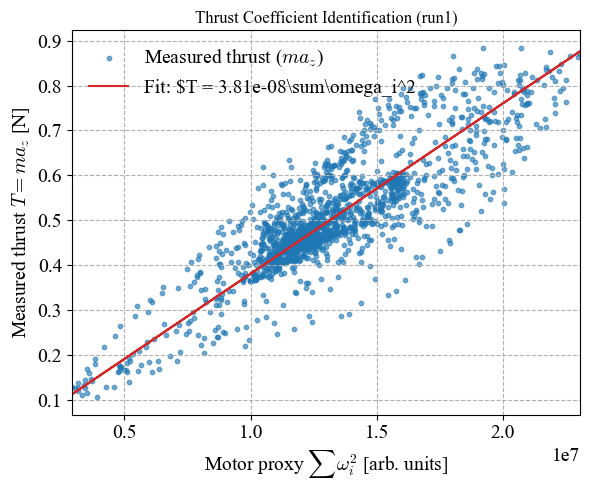

run2: k_T = 3.788e-08 N/(rad/s)²


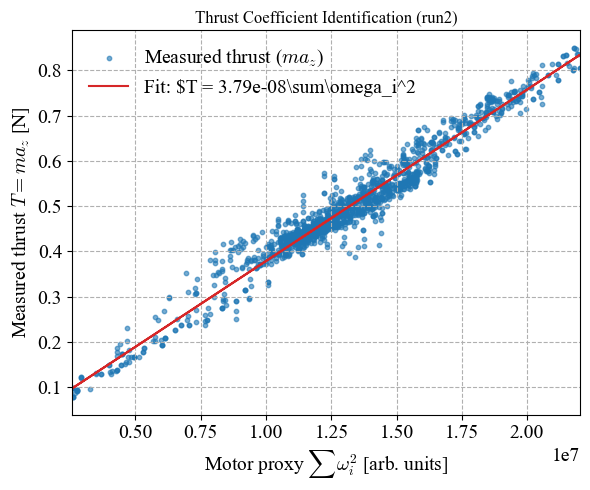

run3: k_T = 3.735e-08 N/(rad/s)²


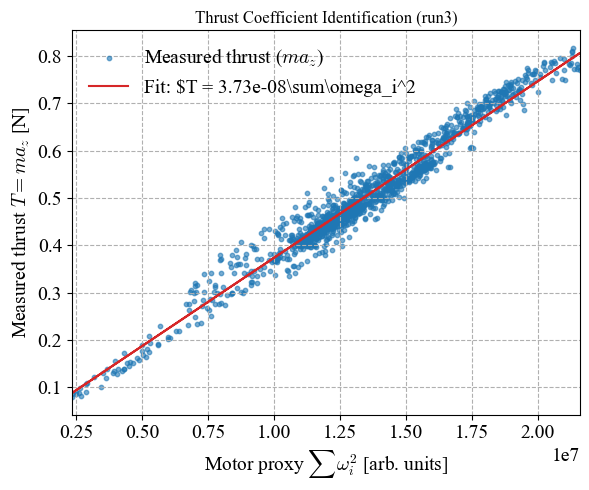

run4: k_T = 3.719e-08 N/(rad/s)²


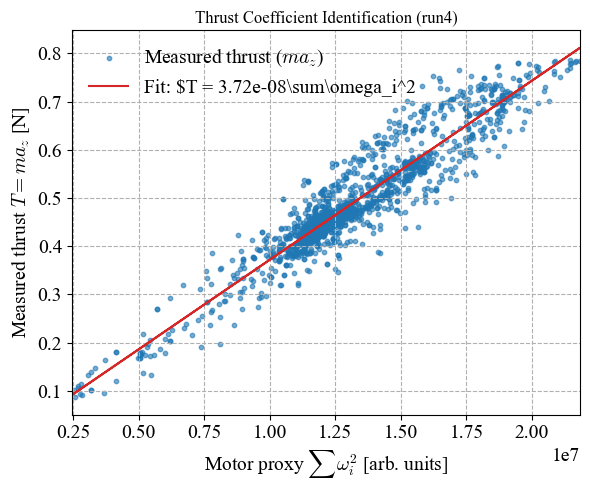


✅ Identification completed and normalized thrust/torques stored in each df_real.


In [390]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- Physical parameters ---
m = 0.045  # kg
g = 9.81
L = 0.04
K_C = 1e-8
thrust_to_weight = 2.0
T_max = m * g * thrust_to_weight
tau_max = np.array([1e-2, 1e-2, 3e-3])

g_body = r_inv.apply([0, 0, g])

for name, df_real in df_real_dict.items():
    # --- True measured thrust (N) ---
    T_meas = (m * (df_real['az_body'].values + g_body[:,-1])).reshape(-1, 1)

    # --- Motor proxy (sum of squared angular speeds) ---
    m_rad2 = {}
    for m_name in ['m1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm']:
        # convert ERPM to rad/s and square
        m_rad2[m_name] = (df_real[m_name] * 2 * np.pi / (6 * 60)) ** 2

    # Sum of all ω²
    T_proxy = (m_rad2['m1_erpm'] + m_rad2['m2_erpm'] +
               m_rad2['m3_erpm'] + m_rad2['m4_erpm']).values.reshape(-1, 1)

    # --- Linear regression: T_meas = k_T * Σω² + b ---
    reg = LinearRegression(fit_intercept=False).fit(T_proxy, T_meas)
    k_T = reg.coef_[0][0]
    # b_T = reg.intercept_[0]
    # print(f"{name}: k_T = {k_T:.3e} N/(rad/s)², b_T = {b_T:.3e} N")
    print(f"{name}: k_T = {k_T:.3e} N/(rad/s)²")

    # --- Per-motor thrust contributions (include ¼ intercept each) ---
    thrust_i = {}
    for key in ['m1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm']:
        thrust_i[key] = k_T * m_rad2[key]# + b_T / 4.0

    # --- Combined identified thrust and torques (in physical units) ---
    thrust_id = sum(thrust_i.values())
    tau_x_id  = L * ((thrust_i['m3_erpm'] + thrust_i['m4_erpm']) -
                     (thrust_i['m1_erpm'] + thrust_i['m2_erpm']))
    tau_y_id  = L * ((thrust_i['m2_erpm'] + thrust_i['m3_erpm']) -
                     (thrust_i['m1_erpm'] + thrust_i['m4_erpm']))
    tau_z_id  = K_C * ((thrust_i['m1_erpm'] + thrust_i['m3_erpm']) -
                       (thrust_i['m2_erpm'] + thrust_i['m4_erpm']))

    # --- Normalize according to physics model convention ---
    df_real['thrust_id'] = thrust_id
    df_real['tau_x_id']  = tau_x_id
    df_real['tau_y_id']  = tau_y_id
    df_real['tau_z_id']  = tau_z_id

    df_real['thrust_id_normed'] = thrust_id / T_max
    df_real['tau_x_id_normed']  = tau_x_id  / tau_max[0]
    df_real['tau_y_id_normed']  = tau_y_id  / tau_max[1]
    df_real['tau_z_id_normed']  = tau_z_id  / tau_max[2]

    # --- Plot regression (optional) ---
    plt.figure(figsize=(6, 5))
    plt.scatter(T_proxy, T_meas, s=10, alpha=0.6, color='tab:blue',
                label=r"Measured thrust ($m a_z$)")
    plt.plot(T_proxy, reg.predict(T_proxy), color='tab:red',
             label=fr"Fit: $T = {k_T:.2e}\sum\omega_i^2")# + {b_T:.2e}$")

    plt.xlabel(r"Motor proxy $\sum \omega_i^2$ [arb. units]")
    plt.ylabel(r"Measured thrust $T = m a_z$ [N]")
    plt.title(f"Thrust Coefficient Identification ({name})")
    plt.legend(frameon=False, loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n✅ Identification completed and normalized thrust/torques stored in each df_real.")

Text(0, 0.5, '[N]')

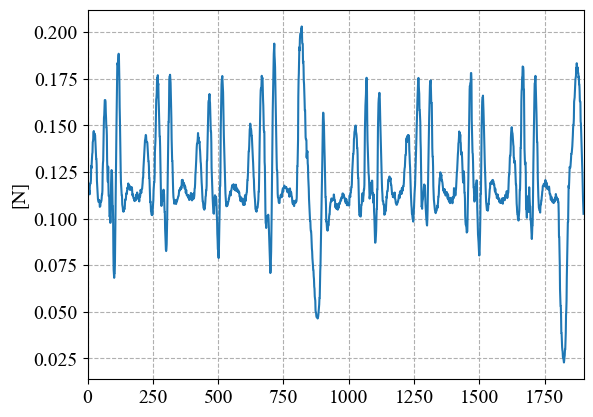

In [391]:
plt.plot(df_real['thrust_id']/4)
plt.ylabel("[N]")

In [406]:
from scipy.signal import butter, filtfilt

# Example parameters
fs = 100        # sampling frequency in Hz (adjust to your data)
cutoff = 5     # cutoff frequency in Hz
order = 3       # filter order
dt = 0.01

# Design filter
b, a = butter(order, cutoff / (0.5 * fs), btype='low')

# Apply filter
wx = pd.Series(filtfilt(b, a, df_real['wx']))
dwx = wx.diff() / dt


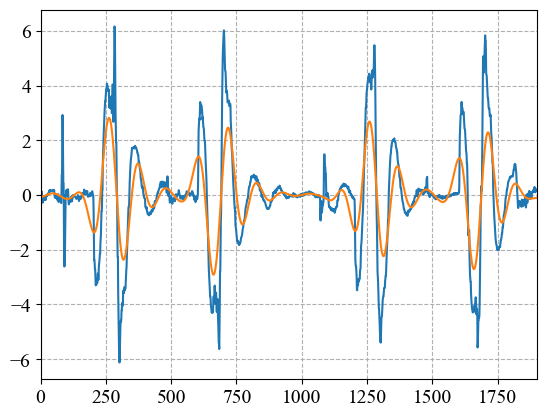

In [407]:
plt.plot(df_real['wx'])
plt.plot(wx)
# plt.plot(dwx)

$J_{xx}\dot{\omega} = \tau_x$

In [408]:
J_xx = 2.3951e-5

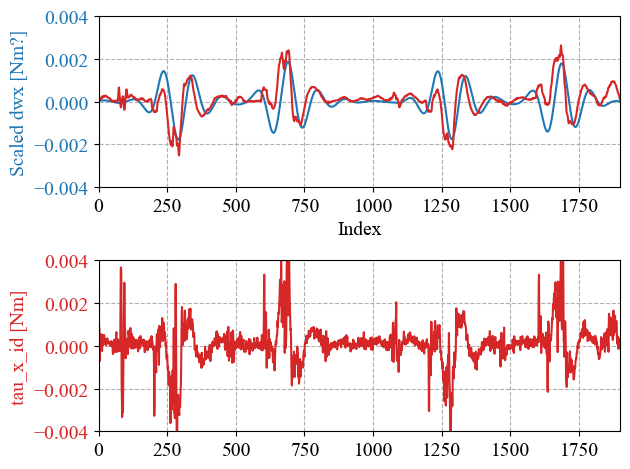

In [411]:
fig, (ax1, ax2) = plt.subplots(2,1)

# Left axis (blue)
ax1.plot((dwx * J_xx), color='tab:blue', label='2.3951e-5 * dwx')
ax1.plot(df_real['tau_x_id'].rolling(20, min_periods=1, center=True).mean(), color='tab:red', label='tau_x_id')
ax1.set_xlabel('Index')
ax1.set_ylabel('Scaled dwx [Nm?]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim([-0.004, 0.004])

# Right axis (red)
ax2.plot(df_real['tau_x_id'], color='tab:red', label='tau_x_id')
ax2.set_ylabel('tau_x_id [Nm]', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(ax1.get_ylim())
# Optional: grid and legend
ax1.grid(True)
fig.tight_layout()

plt.show()


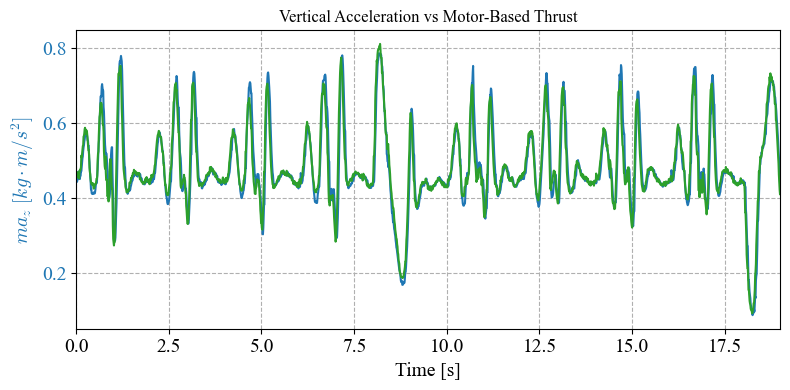

In [399]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 4))

# Left y-axis → acceleration
ax1.plot(df_real['t'], (m * (df_real['az_body'] + g_body[:,-1])), color='tab:blue', label='true')
ax1.plot(df_real['t'], reg.predict(df_real['thrust_motors'].values.reshape(-1, 1)), color='tab:green', label='az (m/s²)')
ax1.set_xlabel("Time [s]")
ax1.set_ylabel(r"$ma_z\ [kg \cdot m/s^2]$", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

plt.title("Vertical Acceleration vs Motor-Based Thrust")
plt.tight_layout()
plt.show()


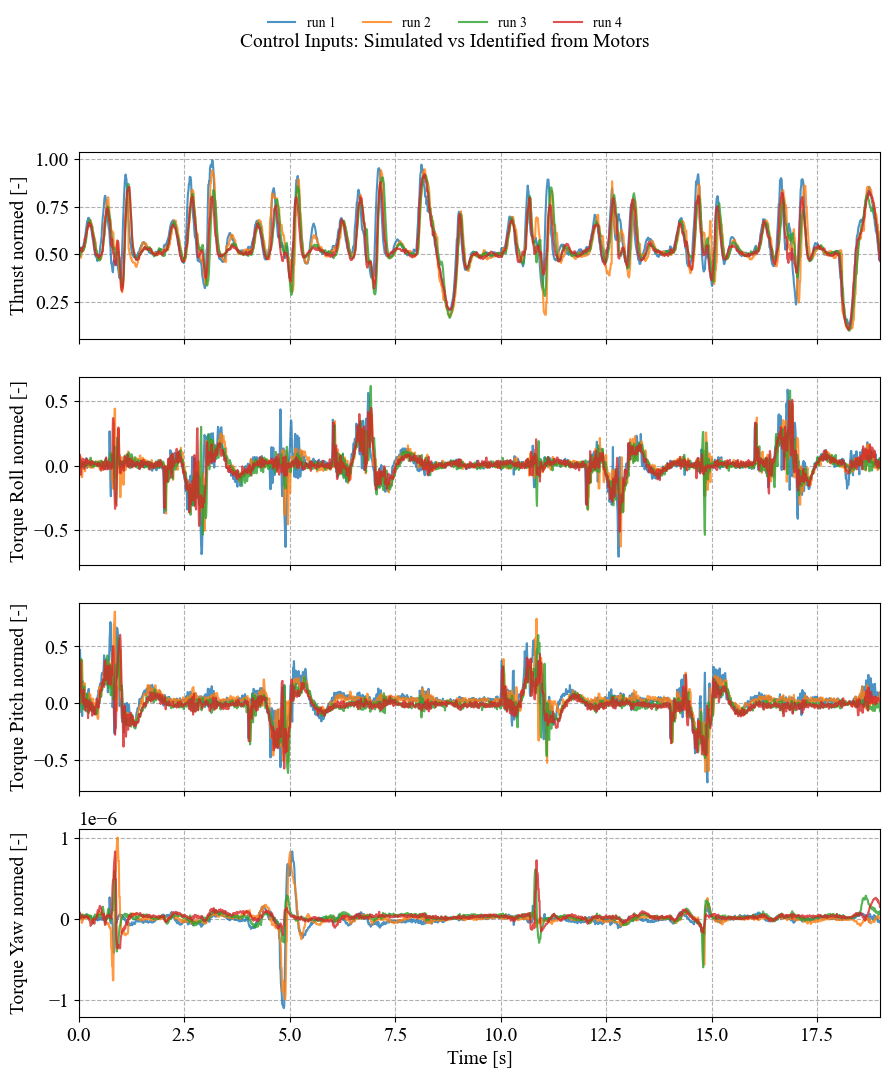

In [401]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define plotting metadata ---
cols_sim = ['thrust', 'torque_roll', 'torque_pitch', 'torque_yaw']
cols_id  = ['thrust_id_normed', 'tau_x_id_normed', 'tau_y_id_normed', 'tau_z_id_normed']
labels   = ["Thrust normed [-]", "Torque Roll normed [-]", "Torque Pitch normed [-]", "Torque Yaw normed [-]"]
colors   = plt.cm.tab10.colors  # distinct colors for runs

# --- Plot setup ---
fig, axs = plt.subplots(4, 1, figsize=(9, 10), sharex=True)
all_handles, all_labels = [], []

for i, (col_sim, col_id, label) in enumerate(zip(cols_sim, cols_id, labels)):
    ax = axs[i]
    ax.grid(True)

    # --- Motor-based identified values (right y-axis) ---
    for j, (name, df_real) in enumerate(df_real_dict.items()):
        label_run = f"run {j+1}" if i == 0 else None  # label only on first plot
        line, = ax.plot(df_real['t'], df_real[col_id],
                         color=colors[j % len(colors)], alpha=0.8, label=label_run)
        ax.set_ylabel(labels[i])
        # Collect handles for the global legend (first row only)
        if i == 0 and label_run:
            all_handles.append(line)
            all_labels.append(label_run)


axs[-1].set_xlabel("Time [s]")
fig.suptitle("Control Inputs: Simulated vs Identified from Motors", fontsize=14, y=1.05)

# --- Global legend (top) ---
ncols_legend = len(all_labels)
fig.legend(all_handles, all_labels,
           loc='upper center', ncols=ncols_legend,
           bbox_to_anchor=(0.5, 1.08), fontsize=10, frameon=False)

# --- Layout cleanup ---
plt.tight_layout(rect=[0, 0, 1, 0.98])
fig.align_ylabels(axs)
plt.show()


In [173]:
0.1 * 0.05

0.005000000000000001

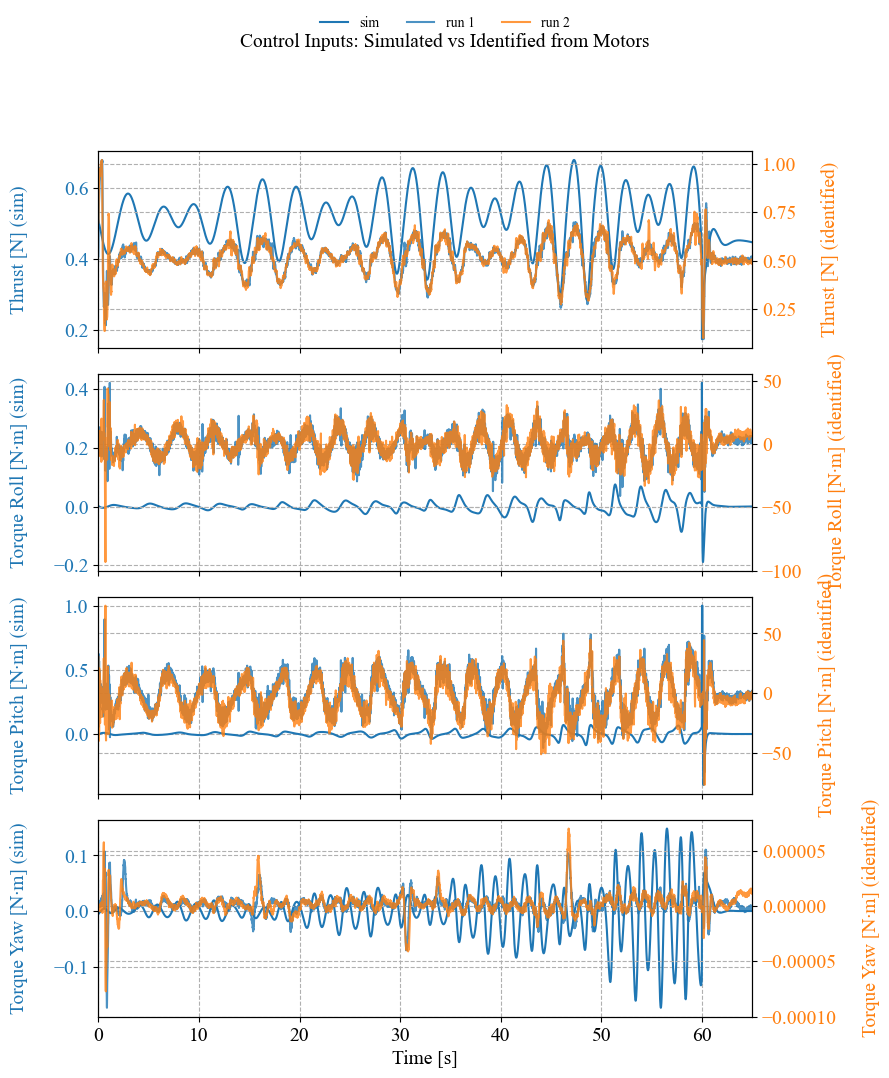

In [134]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define plotting metadata ---
cols_sim = ['thrust', 'torque_roll', 'torque_pitch', 'torque_yaw']
cols_id  = ['thrust_id', 'tau_x_id', 'tau_y_id', 'tau_z_id']
labels   = ["Thrust [N]", "Torque Roll [N·m]", "Torque Pitch [N·m]", "Torque Yaw [N·m]"]
colors   = plt.cm.tab10.colors  # distinct colors for runs

# --- Plot setup ---
fig, axs = plt.subplots(4, 1, figsize=(9, 10), sharex=True)
all_handles, all_labels = [], []

for i, (col_sim, col_id, label) in enumerate(zip(cols_sim, cols_id, labels)):
    ax = axs[i]
    ax2 = ax.twinx()

    # --- Simulation (left y-axis) ---
    sim_line, = ax.plot(df_sim['t'], df_sim[col_sim],
                        color="tab:blue", label="sim")
    ax.set_ylabel(f"{label} (sim)", color="tab:blue", labelpad=18)
    ax.tick_params(axis='y', labelcolor="tab:blue")
    ax.grid(True)

    # --- Motor-based identified values (right y-axis) ---
    for j, (name, df_real) in enumerate(df_real_dict.items()):
        label_run = f"run {j+1}" if i == 0 else None  # label only on first plot
        line, = ax2.plot(df_real['t'], df_real[col_id],
                         color=colors[j % len(colors)], alpha=0.8, label=label_run)

        # Collect handles for the global legend (first row only)
        if i == 0 and label_run:
            all_handles.append(line)
            all_labels.append(label_run)

    # --- Right y-axis setup ---
    ax2.set_ylabel(f"{label} (identified)", color="tab:orange", labelpad=18)
    ax2.tick_params(axis='y', labelcolor="tab:orange")

    # --- Add simulation handle to legend once ---
    if i == 0:
        all_handles.insert(0, sim_line)
        all_labels.insert(0, "sim")

axs[-1].set_xlabel("Time [s]")
fig.suptitle("Control Inputs: Simulated vs Identified from Motors", fontsize=14, y=1.05)

# --- Global legend (top) ---
ncols_legend = len(all_labels)
fig.legend(all_handles, all_labels,
           loc='upper center', ncols=ncols_legend,
           bbox_to_anchor=(0.5, 1.08), fontsize=10, frameon=False)

# --- Layout cleanup ---
plt.tight_layout(rect=[0, 0, 1, 0.98])
fig.align_ylabels(axs)
plt.show()
